# Laboratorio #6

* Josue Say - 228801
* Flavio Galán - 22386

## Repositorio

- [Enlace](https://github.com/JosueSay/labs-ds/tree/main/lab6)
- [Modelos](https://drive.google.com/drive/folders/1dduq-CjuOH54dMHgF7cEy9RE8htZih-i?usp=sharing)

> *Nota:* se está utilizando python *3.12.3* y para no entrenar nuevamente los modelos se recomienda descargar los modelos por el enlace y descomprimirlos, dejar la carpeta `models` dentro de `lab6`.
>
> En la carpeta [docs/algorithms](https://github.com/JosueSay/labs-ds/tree/main/lab6/docs/algorithms) se encuentran los documentos de referencias y explicación de los 2 métodos implementados para que se pueda ver un mayor detalle con un workflow base.


In [1]:
# %pip install -r requirements.txt

## Librerias

In [2]:
# Login y auxiliares
import os
import re
import html
import json
import logging
import unicodedata
from logging.handlers import RotatingFileHandler

# Manejo de texto
import ftfy
from unidecode import unidecode
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from tabulate import tabulate

# Hugging Face (solo para tokenizador/encoder y logs)
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
hf_logging.set_verbosity_error()

# Scikit-learn: extracción de características, modelado y métricas
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Persistencia baseline
from joblib import dump as joblib_dump, load as joblib_load

# PyTorch (para la parte BERT+CNN)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

/nix/store/w708yz0d2n3six7w02m05s4xlff5ivvg-python3-3.12.11-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Constantes

In [3]:
# ========== CONFIG GENERAL ==========
os.environ["TOKENIZERS_PARALLELISM"] = "false"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOGGING_ENABLED   = False
LOG_TO_CONSOLE    = True
LOG_DIR           = "./logs"
LOG_FILE_NAME     = "pipeline.log"
LOG_LEVEL         = logging.INFO
LOG_MAX_BYTES     = 2 * 1024 * 1024       # 2MB
LOG_BACKUP_COUNT  = 3
LOG_SAMPLE_N      = 8

# --------- EJECUCIÓN (on/off) ----------
RUN_FREQUENCIES = True
RUN_NGRAMS      = True
RUN_PLOTS       = True
RUN_MODELS      = False
RUN_THRESHOLD   = False
RUN_BERTCNN     = False

# --------- RUTAS / ARCHIVOS ------------
DATA_DIR     = "data"
RAW_FILE     = "train.csv"
CLEAN_FILE   = "cleaned_train.csv"
USE_CLEANED  = False
DO_CLEANING  = True
SAVE_CLEANED = True

# --------- LIMPIEZA  ---------
REMOVE_URLS       = True
REMOVE_MENTIONS   = True
REMOVE_HASHTAGS   = True
REMOVE_EMOJIS     = True
REMOVE_PUNCT      = True
LOWERCASE         = True
REMOVE_STOPWORDS  = True
STOPWORDS_LANG    = "english"

# --------- BOW / NGRAMS ----------------
VEC_MIN_DF        = 2
NGRAM_MAX         = 2
CHAR_NGRAM_RANGE  = (3,5)

# --------- TRAIN/TEST -------------------
TEST_SIZE         = 0.20
RANDOM_STATE      = 42
CALIBRATE_SVC     = True

# --------- PLOTS ------------------------
SAVE_FIGS         = True
IMAGES_DIR        = "./images"
TOPK_FREQ         = 30
TOPK_NGRAMS       = 20

# --------- BERT + CNN (PyTorch) --------
BERT_MODEL_NAME   = "distilbert-base-uncased"
BERT_MAX_LEN      = 128
BERT_BATCH        = 32
BERT_EPOCHS       = 10
BERT_LR           = 1e-3
CNN_FILTERS       = 32
CNN_KERNEL_SIZE   = 3
CNN_DROPOUT       = 0.5
BERT_TRAINABLE    = False
BERT_THRESHOLD    = 0.50
EARLY_STOP_PATIENCE = 2

# Heurística: ¿mojibake?
MOJIBAKE_PAT = re.compile(
    r"[\uFFFD\u0080-\u009F]"      # U+FFFD o control C1
    r"|Ã.|Â.|â.|Û.|Ò|Ó"
)

# --------- MODELOS (guardar/cargar) ----------
MODELS_DIR              = "./models"

# Baseline (scikit-learn)
SAVE_BASELINE_MODEL     = RUN_MODELS
BASELINE_MODEL_FILE     = "baseline_best.joblib"
BASELINE_LOAD_PATH      = os.path.join(MODELS_DIR, BASELINE_MODEL_FILE)

# BERT + CNN (PyTorch + tokenizer)
SAVE_BERT_MODEL         = RUN_BERTCNN
BERT_ARTIFACT_DIR       = "bert_cnn"
BERT_MODEL_SUBDIR       = "model"
BERT_TOKENIZER_SUBDIR   = "tokenizer"

BERT_MODEL_LOAD_PATH    = os.path.join(MODELS_DIR, BERT_ARTIFACT_DIR, BERT_MODEL_SUBDIR)
BERT_TOKENIZER_LOAD_PATH= os.path.join(MODELS_DIR, BERT_ARTIFACT_DIR, BERT_TOKENIZER_SUBDIR)

### Documentación

**Config general y logging:**

| Constante                              | ¿Qué hace?                                            | Tipo / opciones                             | Notas                                                            |
| -------------------------------------- | ----------------------------------------------------- | ------------------------------------------- | ---------------------------------------------------------------- |
| `os.environ["TOKENIZERS_PARALLELISM"]` | Controla el paralelismo de tokenizers HF.             | `"true"` / `"false"`                        | En `"false"` para evitar *warnings* en CPU.               |
| `DEVICE`                               | Dispositivo para PyTorch.                             | `torch.device("cuda")` / `"cpu"`            | Auto-detección por `cuda.is_available()`. |
| `LOGGING_ENABLED`                      | Activa/desactiva logs del pipeline.                   | `bool`                                      | Si `False`, se minimiza salida de logging.                       |
| `LOG_TO_CONSOLE`                       | También imprime logs en consola.                      | `bool`                                      | Útil en desarrollo.                                              |
| `LOG_DIR`                              | Carpeta de logs.                                      | `str` (ruta)                                | Se crea si no existe.                                            |
| `LOG_FILE_NAME`                        | Archivo principal de log.                             | `str`                                       | Rotado con tamaño.                                               |
| `LOG_LEVEL`                            | Nivel de log.                                         | `logging.DEBUG/INFO/WARNING/ERROR/CRITICAL` | Recomendado `INFO` en producción, `DEBUG` al depurar.            |
| `LOG_MAX_BYTES`                        | Tamaño máx. por archivo antes de rotar.               | `int` (bytes)                               | Ej.: `2*1024*1024` (2MB).                                        |
| `LOG_BACKUP_COUNT`                     | Cuántos archivos de respaldo guardar.                 | `int`                                       | Rotación de logs.                                                |
| `LOG_SAMPLE_N`                         | Muestras "antes/después" que se imprimen de limpieza. | `int`                                       | Para inspección rápida.                                          |

**Switches de ejecución (on/off):**

| Constante         | ¿Qué ejecuta?                                      | Tipo / opciones | Notas                                         |
| ----------------- | -------------------------------------------------- | --------------- | --------------------------------------------- |
| `RUN_FREQUENCIES` | Conteo de unigramas y tablas por clase.            | `bool`          | Paso descriptivo.                             |
| `RUN_NGRAMS`      | Top de n-gramas (uni/bi/tri según config).         | `bool`          | Contexto léxico.                              |
| `RUN_PLOTS`       | Nubes de palabras e histogramas.                   | `bool`          | Guarda en `IMAGES_DIR` si `SAVE_FIGS`.        |
| `RUN_MODELS`      | Entrena/evalúa la **línea base** (scikit-learn).   | `bool`          | Genera `baseline_best.joblib` si se guarda.   |
| `RUN_THRESHOLD`   | Búsqueda de umbral óptimo (si el clf tiene proba). | `bool`          | Solo para clasificadores con `predict_proba`. |
| `RUN_BERTCNN`     | Entrena/evalúa **DistilBERT+CNN (PyTorch)**.       | `bool`          | Genera archivos en `models/bert_cnn/`.      |

**Rutas / archivos de datos:**

| Constante      | ¿Qué hace?                             | Tipo / opciones | Notas                                |
| -------------- | -------------------------------------- | --------------- | ------------------------------------ |
| `DATA_DIR`     | Carpeta de datos.                      | `str`           | Ej. `data`.                          |
| `RAW_FILE`     | CSV crudo.                             | `str`           | Ej. `train.csv`.                     |
| `CLEAN_FILE`   | CSV limpio a cachear.                  | `str`           | Ej. `cleaned_train.csv`.             |
| `USE_CLEANED`  | Si existe `CLEAN_FILE`, usarlo. | `bool`          | Ahorra tiempo en corridas repetidas. |
| `DO_CLEANING`  | Limpia el crudo si no hay limpio.      | `bool`          | Aplica tu pipeline de limpieza.      |
| `SAVE_CLEANED` | Guarda el resultado limpio.            | `bool`          | Útil para caché local.               |

**Limpieza:**

| Constante          | ¿Qué hace?                            | Tipo / opciones                      |
| ------------------ | ------------------------------------- | ------------------------------------ |
| `REMOVE_URLS`      | Quita URLs.                           | `bool`                               |
| `REMOVE_MENTIONS`  | Quita `@usuario`.                     | `bool`                               |
| `REMOVE_HASHTAGS`  | Quita `#hashtag` (el token completo). | `bool`                               |
| `REMOVE_EMOJIS`    | Quita emojis y símbolos misceláneos.  | `bool`                               |
| `REMOVE_PUNCT`     | Quita puntuación.                     | `bool`                               |
| `LOWERCASE`        | Convierte a minúsculas.               | `bool`                               |
| `REMOVE_STOPWORDS` | Quita stopwords del idioma.           | `bool`                               |
| `STOPWORDS_LANG`   | Idioma de stopwords.                  | `str` (ej. `"english"`, `"spanish"`) |

**BOW / N-grams:**

| Constante          | ¿Qué hace?                            | Tipo / opciones  | Notas                                    |
| ------------------ | ------------------------------------- | ---------------- | ---------------------------------------- |
| `VEC_MIN_DF`       | Mín. df para incluir un término.      | `int` >= 1        | Sub-muros: elimina términos muy raros. |
| `NGRAM_MAX`        | Máx. n de palabras (1=uni, 2=uni+bi). | `int` >= 1        |                     |
| `CHAR_NGRAM_RANGE` | Rango de n-gramas de **caracteres**.  | `tuple(int,int)` | Ej. `(3,5)` capturan variantes y typos.  |

**Train/Test (scikit-learn):**

| Constante       | ¿Qué hace?                             | Tipo / opciones | Notas                         |
| --------------- | -------------------------------------- | --------------- | ----------------------------- |
| `TEST_SIZE`     | Proporción para test.                  | `float` (0–1)   | Ej. `0.2` = 80/20.            |
| `RANDOM_STATE`  | Semilla de *split*.                    | `int`           | Reproducibilidad.             |
| `CALIBRATE_SVC` | Calibra LinearSVC para probabilidades. | `bool`          | Usa `CalibratedClassifierCV`. |

**Plots:**

| Constante     | ¿Qué hace?                        | Tipo / opciones |
| ------------- | --------------------------------- | --------------- |
| `SAVE_FIGS`   | Guarda figuras a disco.           | `bool`          |
| `IMAGES_DIR`  | Carpeta de imágenes.              | `str`           |
| `TOPK_FREQ`   | Top-K términos para tablas/plots. | `int`           |
| `TOPK_NGRAMS` | Top-K n-gramas (k>=2) para tablas. | `int`           |

**BERT + CNN (PyTorch):**

| Constante             | ¿Qué hace?                            | Tipo / opciones      | Notas                                                   |
| --------------------- | ------------------------------------- | -------------------- | ------------------------------------------------------- |
| `BERT_MODEL_NAME`     | Backbone HF a usar.                   | `str` (ID HF)        |         |
| `BERT_MAX_LEN`        | Tokens máx. del *sequence length*.    | `int` (p.ej. 64–256) | 128 cubre casi todos los tweets.                        |
| `BERT_BATCH`          | Tamaño de batch.                      | `int`                | Ajusta por memoria (CPU/GPU).                           |
| `BERT_EPOCHS`         | Épocas máximas.                       | `int`                |                   |
| `BERT_LR`             | Learning rate de la **cabeza**.       | `float`              |      |
| `CNN_FILTERS`         | Nº de filtros Conv1D.                 | `int`                | 32–128 típico.                                          |
| `CNN_KERNEL_SIZE`     | Ancho del kernel (n-grama "virtual"). | `int`                | 3 = trigrama; puede probarse 3/4/5                      |
| `CNN_DROPOUT`         | Dropout tras pooling.                 | `float` (0–1)        | 0.3–0.5 recomendado.                                    |
| `BERT_TRAINABLE`      | Descongelar/congelar encoder.         | `bool`               | `False` = más rápido en CPU; `True` = mejor si hay GPU. |
| `BERT_THRESHOLD`      | Umbral de decisión para clase 1.      | `float` (0–1)        |                          |
| `EARLY_STOP_PATIENCE` | Paciencia para *early stopping*.      | `int` >= 1            | Evalúa `val_loss`.                                      |

**Heurística de texto ambiguo:**

| Constante      | ¿Qué hace?                      | Tipo / opciones |
| -------------- | ------------------------------- | --------------- |
| `MOJIBAKE_PAT` | Regex para detectar "mojibake". | `re.Pattern`    |

**Modelos (guardar/cargar):**

| Constante                  | ¿Qué hace?                     | Tipo / opciones | Notas                                 |
| -------------------------- | ------------------------------ | --------------- | ------------------------------------- |
| `MODELS_DIR`               | Carpeta raíz de modelos.       | `str`           | Se crea si no existe.                 |
| `SAVE_BASELINE_MODEL`      | Guardar pipeline baseline.     | `bool`          | Guarda vectorizador+clf juntos.       |
| `BASELINE_MODEL_FILE`      | Nombre del .joblib.            | `str`           |            |
| `BASELINE_LOAD_PATH`       | Ruta de carga baseline.        | `str`           |                   |
| `SAVE_BERT_MODEL`          | Guardar artefactos BERT+CNN.   | `bool`          | Guarda tokenizer + `state_dict`/meta. |
| `BERT_ARTIFACT_DIR`        | Subcarpeta de BERT.            | `str`           |                        |
| `BERT_MODEL_SUBDIR`        | Carpeta del **modelo**.        | `str`           |                           |
| `BERT_TOKENIZER_SUBDIR`    | Carpeta del **tokenizer**.     | `str`           |                       |
| `BERT_MODEL_LOAD_PATH`     | Ruta de carga del modelo BERT. | `str`           | `.../bert_cnn/model`.                 |
| `BERT_TOKENIZER_LOAD_PATH` | Ruta de carga del tokenizer.   | `str`           | `.../bert_cnn/tokenizer`.             |

## Helpers

Funciones adicionales que servirán para el código implementado.

In [4]:
def printTable(df: pd.DataFrame, title: str = "", n: int = 20) -> None:
    if title: print(f"\n=== {title} ===")
    print(tabulate(df.head(n), headers='keys', tablefmt='github', showindex=False))

Se utiliza para imprimir tablas para debug/log.

In [5]:
def ensureDir(path: str) -> bool:
    try:
        os.makedirs(path, exist_ok=True)
        return True
    except Exception as e:
        print(f"[ensureDir] Error: {e}")
        return False

def initLogger(name: str = "lab6") -> logging.Logger:
    ensureDir(LOG_DIR)
    logger = logging.getLogger(name)
    logger.setLevel(LOG_LEVEL)
    logger.handlers.clear()
    fh = RotatingFileHandler(os.path.join(LOG_DIR, LOG_FILE_NAME),
                             maxBytes=LOG_MAX_BYTES, backupCount=LOG_BACKUP_COUNT,
                             encoding="utf-8")
    fmt = logging.Formatter("[%(asctime)s] %(levelname)s - %(message)s",
                            datefmt="%Y-%m-%d %H:%M:%S")
    fh.setFormatter(fmt); logger.addHandler(fh)
    if LOG_TO_CONSOLE:
        ch = logging.StreamHandler(); ch.setFormatter(fmt); logger.addHandler(ch)
    logger.propagate = False
    if LOGGING_ENABLED:
        logger.info("=== Logger inicializado ===")
    return logger

def logSection(logger: logging.Logger, title: str):
    if LOGGING_ENABLED:
        logger.info("")
        logger.info("=" * (len(title) + 8))
        logger.info(f"==  {title}  ==")
        logger.info("=" * (len(title) + 8))

Este trío forma el "sistema de bitácora" del proyecto:

- `ensureDir` es el guardia de seguridad que se asegura de que exista la carpeta donde escribir (crea `path` con `os.makedirs(..., exist_ok=True)` y devuelve `True` si todo bien o `False` si falló, dejando el error impreso).

- `initLogger` monta sobre esa carpeta un logger.
    - crea (o valida) `LOG_DIR`
    - obtiene un `logging.Logger` con nombre (por defecto `"lab6"`)
    - fija el nivel `LOG_LEVEL`
    - limpia handlers previos para evitar mensajes duplicados
    - añade un `RotatingFileHandler` apuntando a `LOG_FILE_NAME` con rotación por tamaño (`maxBytes=LOG_MAX_BYTES`, `backupCount=LOG_BACKUP_COUNT`, codificación UTF-8) y un formato uniforme `[fecha hora] NIVEL - mensaje`
    - si `LOG_TO_CONSOLE` es `True` agrega también un `StreamHandler` a consola con el mismo formato; desactiva `propagate` para que los mensajes no se repliquen a loggers ancestros y, si `LOGGING_ENABLED` está activo, escribe un **"Logger inicializado"** de bienvenida
    - finalmente devuelve el `logger` configurado.

- `logSection` es un pequeño helper estético que, usando ese mismo `logger`, imprime un salto de línea y un encabezado alrededor del título que se le pase

## Data Cleaning

Hay tres piezas: un detector de "texto roto", un reparador de codificación y el limpiador principal que aplica reglas sobre todo el DataFrame.

**Reparación de codificación (antes de todo):**

* **`looksMojibake(t)`**
  Chequea con una **expresión regular** si el texto trae "símbolos raros" típicos de mala decodificación (`Ã`, `Â`, `�`, etc.).
* **`autoFixEncoding(t)`**

  1. Intenta **arreglar con `ftfy.fix_text`** (arregla comillas curvas, mojibake frecuente, espacios raros).
  2. Si aún "huele a mojibake", prueba una **re-decoding heurística**: toma los bytes como si fueran `latin1/cp1252` y los **decodifica como UTF-8**.
  3. Si nada aplica, **devuelve el original**.
     *¿Para qué?* Para evitar tokens basura tipo "ÂÂfire" que confunden al modelo.

**Limpieza "lingüística" (por columnas):**

La función **`cleaningData(df)`** aplica, en este orden, sobre `df["text"]`:

1. **Relleno de nulos**: `NA -> ""`.
2. **Desescape HTML**: `html.unescape` (convierte `&amp;` -> `&`, etc.).
3. **Arreglo de codificación**: `autoFixEncoding` (ver arriba).
4. **Normalización Unicode (NFKC)**: homogeneiza formas equivalentes (espacios, signos, letras compuestas).
5. **Eliminación de URLs** *(si `REMOVE_URLS=True`)*: borra `http(s)://…` y `www.…`.
6. **Eliminación de menciones** *(si `REMOVE_MENTIONS=True`)*: quita `@usuario`.
7. **Eliminación de hashtags** *(si `REMOVE_HASHTAGS=True`)*: quita `#palabra` (el hash y el token).
8. **Eliminación de emojis/símbolos** *(si `REMOVE_EMOJIS=True`)*: limpia rangos U+1F300–1FAFF y ☀–⛿.
9. **Eliminación de puntuación** *(si `REMOVE_PUNCT=True`)*: deja solo letras/dígitos/espacios.
10. **Limpieza de guiones bajos**: colapsa `_` residuales.
11. **Transliteración a ASCII** con **`unidecode`**: `café -> cafe`, `niño -> nino`. *(En este script está activado por defecto; útil para modelos basados en n-gramas de caracteres.)*
12. **(Opcional) Forzar ASCII-only**: si estuviera activo, eliminaría cualquier carácter no ASCII. *(Aquí está desactivado.)*
13. **Minúsculas** *(si `LOWERCASE=True`)*.
14. **Espacios**: colapsa múltiples espacios y hace *trim*.
15. **Stopwords** *(si `REMOVE_STOPWORDS=True`)*: quita artículos/preposiciones/conjunciones en **inglés** usando `nltk.corpus.stopwords`.

> **Nota de diseño (orden importa):** URLs/mentions/hashtags se quitan **antes** de la puntuación para no romper los patrones; minúsculas se aplican **al final**; la normalización Unicode + `ftfy` van **al inicio** para estabilizar el texto que sigue.

**Finalmente:**

Si `LOGGING_ENABLED=True`, la función:

* Reporta **# de filas** y **nulos en `text`**.
* Muestra **N ejemplos "antes -> después"** (controlado por `LOG_SAMPLE_N`).
* Calcula la **longitud media del texto** antes y después y la **% de reducción** (útil para auditar cuánto ruido se quitó).

In [6]:
def looksMojibake(t: str) -> bool:
    return bool(MOJIBAKE_PAT.search(t))

def autoFixEncoding(t: str) -> str:
    if not t:
        return t
    try:
        fixed = ftfy.fix_text(t)
        if fixed != t:
            return fixed
    except Exception:
        pass
    if looksMojibake(t):
        for enc in ("latin1", "cp1252"):
            try:
                b = t.encode('latin1', errors='ignore')
                return b.decode('utf-8', errors='ignore')
            except Exception:
                pass
    return t

In [7]:
def cleaningData(df: pd.DataFrame,
                 log: bool = LOGGING_ENABLED,
                 logger: logging.Logger | None = None,
                 sample_n: int = LOG_SAMPLE_N) -> pd.DataFrame:
    if logger is None:
        logger = logging.getLogger("lab6")
    if log:
        logSection(logger, "LIMPIEZA")
        logger.info(f"Filas: {len(df)} | nulos(text): {df['text'].isna().sum()}")

    has_id = 'id' in df.columns
    if log:
        sample = df.sample(min(sample_n, len(df)), random_state=RANDOM_STATE)[['text']].copy()
        if has_id:
            sample = df[['id','text']].loc[sample.index].copy()

    s = df['text'].fillna('').astype(str).apply(html.unescape)
    s = s.apply(autoFixEncoding)
    s = s.apply(lambda t: unicodedata.normalize("NFKC", t))
    if REMOVE_URLS:       s = s.str.replace(r'(https?://\S+|www\.\S+)', ' ', regex=True)
    if REMOVE_MENTIONS:   s = s.str.replace(r'@\w+', ' ', regex=True)
    if REMOVE_HASHTAGS:   s = s.str.replace(r'#\w+', ' ', regex=True)
    if REMOVE_EMOJIS:     s = s.str.replace(r'[\U0001F300-\U0001FAFF\u2600-\u26FF]+', ' ', regex=True)
    if REMOVE_PUNCT:      s = s.str.replace(r"[^\w\s]", " ", regex=True)
    s = s.str.replace(r"_+", " ", regex=True)
    try:
        if True: s = s.apply(unidecode)
    except Exception:
        pass
    s = s.str.replace(r"[^\x00-\x7F]+", " ", regex=True) if False else s
    if LOWERCASE:         s = s.str.lower()
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    if REMOVE_STOPWORDS:
        stp = set(stopwords.words(STOPWORDS_LANG))
        s = s.apply(lambda t: " ".join(w for w in t.split() if w not in stp))

    out = df.copy(); out['text'] = s

    if log:
        lens_before = df['text'].fillna("").astype(str).str.len()
        lens_after  = out['text'].str.len()
        red_mean = (1 - (lens_after.mean() / (lens_before.replace(0,1)).mean())) * 100
        logger.info(f"Longitud media antes: {lens_before.mean():.1f} | después: {lens_after.mean():.1f} | reducción≈{red_mean:.1f}%")
        logger.info("Muestras de limpieza (antes -> después):")
        for idx in sample.index:
            orig = df.loc[idx, 'text']; clean = out.loc[idx, 'text']
            pre = (orig[:180] + "…") if len(orig) > 180 else orig
            pos = (clean[:180] + "…") if len(clean) > 180 else clean
            if has_id: logger.info(f"[id={df.loc[idx,'id']}]")
            logger.info(f"  BEFORE: {pre}"); logger.info(f"  AFTER : {pos}")
    return out

## Análisis previo para implementar modelos

In [8]:
def loadDataset(dataDir: str = DATA_DIR,
                rawFile: str = RAW_FILE,
                cleanFile: str = CLEAN_FILE,
                useCleaned: bool = True,
                doCleaning: bool = False,
                saveCleaned: bool = False,
                cleaningFn=cleaningData) -> dict:
    clean_path = os.path.join(dataDir, cleanFile)
    raw_path   = os.path.join(dataDir, rawFile)
    artifacts, did_clean = [], False

    if useCleaned and os.path.exists(clean_path):
        df = pd.read_csv(clean_path); used = clean_path
    else:
        df = pd.read_csv(raw_path); used = raw_path
        if doCleaning and (cleaningFn is not None):
            df = cleaningFn(df); did_clean = True
            if saveCleaned:
                ensureDir(dataDir); df.to_csv(clean_path, index=False); artifacts.append(clean_path)

    if 'text' not in df.columns or 'target' not in df.columns:
        raise ValueError("El CSV debe contener 'text' y 'target'.")
    df['text'] = df['text'].fillna('')
    df['target'] = df['target'].astype(int)
    return {'df': df, 'usedFile': used, 'didCleaning': did_clean, 'artifacts': artifacts}

1. **Arma rutas**:

   * `clean_path = dataDir/cleanFile`
   * `raw_path   = dataDir/rawFile`
2. **Decide qué leer**:

   * Si `useCleaned` **y** existe `clean_path` -> lee **`clean_path`**.
   * Si no, lee **`raw_path`** (CSV crudo).
3. **Limpia opcionalmente**:

   * Si leyó el crudo **y** `doCleaning=True` **y** hay `cleaningFn`:

     * Aplica `cleaningFn(df)`.
     * Marca `did_clean = True`.
     * Si `saveCleaned=True`, crea carpeta si hace falta y **guarda** `clean_path`, registrándolo en `artifacts`.
4. **Validación de esquema**:

   * Verifica que existan columnas **`text`** y **`target`**. Si faltan -> `ValueError`.
5. **Normaliza tipos**:

   * `text`: rellena `NaN` con `""`.
   * `target`: castea a **`int`**.
6. **Devuelve un paquete**:

   ```python
   {
     'df': df,                        # DataFrame listo para modelar
     'usedFile': used,                # ruta del archivo realmente usado (clean o raw)
     'didCleaning': did_clean,        # si se limpió en esta corrida
     'artifacts': artifacts           # rutas de archivos generados (p.ej., cleaned CSV)
   }
   ```

### Frecuencias

In [9]:
def computeFrequencies(df: pd.DataFrame, minDf: int = VEC_MIN_DF, topK: int = TOPK_FREQ,
                       verbose: bool = True, log: bool = LOGGING_ENABLED, logger=None):
    if logger is None: logger = logging.getLogger("lab6")
    if log: logSection(logger, "FRECUENCIAS (unigramas)")
    cv = CountVectorizer(ngram_range=(1,1), min_df=minDf)
    X = cv.fit_transform(df['text']); vocab = cv.get_feature_names_out()
    if log: logger.info(f"Vocabulario (uni): {len(vocab)} | min_df={minDf}")

    mask_pos = (df['target']==1).values; mask_neg = ~mask_pos
    counts_pos = X[mask_pos].sum(axis=0).A1
    counts_neg = X[mask_neg].sum(axis=0).A1
    counts_all = X.sum(axis=0).A1

    freq_df = pd.DataFrame({'token': vocab,'pos':counts_pos,'neg':counts_neg,'total':counts_all})
    freq_df['lift_pos'] = (freq_df['pos']+1)/(freq_df['neg']+1)
    freq_df['lift_neg'] = (freq_df['neg']+1)/(freq_df['pos']+1)

    top_pos = freq_df.sort_values(['pos','lift_pos'], ascending=False).head(topK)
    top_neg = freq_df.sort_values(['neg','lift_neg'], ascending=False).head(topK)
    intersect = freq_df[(freq_df['pos']>0)&(freq_df['neg']>0)].sort_values('total', ascending=False).head(topK)

    if log:
        logger.info(f"TOP{topK} pos: {', '.join(top_pos['token'].tolist()[:15])}…")
        logger.info(f"TOP{topK} neg: {', '.join(top_neg['token'].tolist()[:15])}…")
        logger.info(f"Intersección TOP{topK}: {', '.join(intersect['token'].tolist()[:15])}…")

    if verbose:
        printTable(top_pos[['token','pos','lift_pos']], "Top en DESASTRES (pos)", n=topK)
        printTable(top_neg[['token','neg','lift_neg']], "Top en NO DESASTRES (neg)", n=topK)
        printTable(intersect[['token','pos','neg','total']], "Términos en ambas categorías", n=topK)

    return {'params': {'minDf': minDf, 'topK': topK},
            'freqDf': freq_df, 'topPos': top_pos, 'topNeg': top_neg,
            'intersect': intersect, 'vectorizer': cv}

Calcula **frecuencias de unigramas** (palabras sueltas) por clase: *desastre* (`target=1`) vs *no desastre* (`target=0`), y arma tablas útiles para explorar vocabulario discriminativo.

1. **Vectoriza** el texto con `CountVectorizer(ngram_range=(1,1), min_df=minDf)`: construye el vocabulario de unigramas y una matriz `X` (documento \* término) con **conteos**.
2. Separa los tweets por clase con máscaras (`mask_pos`, `mask_neg`) y **suma** conteos por término para cada clase: `counts_pos`, `counts_neg`, y totales `counts_all`.
3. Construye `freq_df` con columnas:

    * `token`, `pos` (frecuencia en desastres), `neg` (frecuencia en no desastres), `total`.
    * **Lift** por clase con *suavizado de +1*:

      * `lift_pos = (pos+1)/(neg+1)` (qué tanto un término es más propio de la clase positiva).
      * `lift_neg = (neg+1)/(pos+1)` (análoga para la negativa).
4. Genera tres vistas ordenadas:

    * `top_pos`: términos más **frecuentes** en desastres (desempata con `lift_pos`).
    * `top_neg`: términos más **frecuentes** en no desastres (desempata con `lift_neg`).
    * `intersect`: términos que aparecen en **ambas** clases, ordenados por `total`.
5. Si `log=True`, escribe resúmenes al logger (tamaños y top-terms).
    Si `verbose=True`, imprime tablas bonitas con `printTable(...)`.

### N-Gramas

In [10]:
def analyzeNgrams(df: pd.DataFrame, nMax: int = NGRAM_MAX, minDf: int = VEC_MIN_DF,
                  topK: int = TOPK_NGRAMS, verbose: bool = True):
    cv = CountVectorizer(ngram_range=(1, nMax), min_df=minDf)
    X = cv.fit_transform(df['text']); vocab = cv.get_feature_names_out()
    mask_pos = (df['target'] == 1).values; mask_neg = (df['target'] == 0).values
    pos_n = X[mask_pos].sum(axis=0).A1; neg_n = X[mask_neg].sum(axis=0).A1
    total = pos_n + neg_n

    df_all = pd.DataFrame({'token': vocab, 'pos': pos_n, 'neg': neg_n, 'total': total})
    df_all['n'] = df_all['token'].str.count(' ') + 1

    byN, tops = {}, {}
    for k in range(2, nMax+1):
        filt = df_all[df_all['n'] == k].sort_values('total', ascending=False)
        tops[k] = filt.head(topK).copy(); byN[k] = filt
        if verbose: printTable(tops[k][['token','pos','neg','total']], f"Top {k}-gramas", n=topK)
    return {'params': {'nMax': nMax, 'minDf': minDf, 'topK': topK}, 'byN': byN, 'tops': tops, 'vectorizer': cv}

Explorar **n-gramas de palabras** (bigramas, trigramas, …) para capturar **contexto** que los unigramas no ven (ej.: `forest fire`, `oil spill`, `heat wave`).


1. **Vectoriza** con `CountVectorizer(ngram_range=(1, nMax), min_df=minDf)`: construye una matriz de conteos que incluye unigramas hasta n-gramas de tamaño `nMax`.
2. Separa por clase (`target==1` vs `target==0`) y **suma** conteos para cada término -> `pos_n`, `neg_n`; también calcula el **total** (`pos+neg`).
3. Arma `df_all` con columnas:

    * `token` (el n-grama), `pos`, `neg`, `total`.
    * `n` = longitud del n-grama (contando espacios + 1).
4. Para cada `k` en `2..nMax` filtra los n-gramas de longitud `k`, los **ordena por `total`** (más frecuentes primero) y guarda:

    * `byN[k]`: **todos** los k-gramas con sus conteos.
    * `tops[k]`: el **Top-K** más frecuentes.
      Si `verbose=True`, imprime una tabla bonita de cada Top-K con `printTable(...)`.

### Visualización de data

In [11]:
def generateWordClouds(topPos: pd.DataFrame, topNeg: pd.DataFrame,
                       saveFigures: bool = SAVE_FIGS, imagesDir: str = IMAGES_DIR, prefix: str = "wc_"):
    artifacts = [];  ensureDir(imagesDir) if saveFigures else None
    # POS
    freq_pos = dict(zip(topPos['token'], topPos['pos']))
    plt.figure(figsize=(8,5))
    wc_pos = WordCloud(width=900, height=400, background_color='white').generate_from_frequencies(freq_pos)
    plt.imshow(wc_pos); plt.axis('off'); plt.title('Desastres (Top Unigramas)')
    if saveFigures:
        path = os.path.join(imagesDir, f"{prefix}desastres.png")
        plt.savefig(path, bbox_inches='tight', dpi=150); artifacts.append(path)
    plt.show()
    # NEG
    freq_neg = dict(zip(topNeg['token'], topNeg['neg']))
    plt.figure(figsize=(8,5))
    wc_neg = WordCloud(width=900, height=400, background_color='white').generate_from_frequencies(freq_neg)
    plt.imshow(wc_neg); plt.axis('off'); plt.title('No desastres (Top Unigramas)')
    if saveFigures:
        path = os.path.join(imagesDir, f"{prefix}no_desastres.png")
        plt.savefig(path, bbox_inches='tight', dpi=150); artifacts.append(path)
    plt.show()
    return {'artifacts': artifacts, 'figures': ['wc_pos','wc_neg']}


In [12]:
def plotTopHistograms(topPos: pd.DataFrame, topNeg: pd.DataFrame,
                      saveFigures: bool = SAVE_FIGS, imagesDir: str = IMAGES_DIR, prefix: str = "hist_"):
    artifacts = []; ensureDir(imagesDir) if saveFigures else None
    # DESASTRES
    tp = topPos.sort_values('pos', ascending=False).head(20)
    plt.figure(figsize=(10,5))
    plt.bar(tp['token'], tp['pos']); plt.xticks(rotation=70, ha='right')
    plt.title('Top-20 palabras en DESASTRES'); plt.ylabel('Frecuencia'); plt.xlabel('Término')
    plt.tight_layout()
    if saveFigures:
        path = os.path.join(imagesDir, f"{prefix}desastres.png")
        plt.savefig(path, bbox_inches='tight', dpi=150); artifacts.append(path)
    plt.show()
    # NO DESASTRES
    tn = topNeg.sort_values('neg', ascending=False).head(20)
    plt.figure(figsize=(10,5))
    plt.bar(tn['token'], tn['neg']); plt.xticks(rotation=70, ha='right')
    plt.title('Top-20 palabras en NO DESASTRES'); plt.ylabel('Frecuencia'); plt.xlabel('Término')
    plt.tight_layout()
    if saveFigures:
        path = os.path.join(imagesDir, f"{prefix}no_desastres.png")
        plt.savefig(path, bbox_inches='tight', dpi=150); artifacts.append(path)
    plt.show()
    return {'artifacts': artifacts}


## Implementación de modelos

### Primer modelo - TF-IDF + Clasificador Lineal

In [13]:
def saveBaselineModel(pipeline, modelsDir: str = MODELS_DIR, filename: str = BASELINE_MODEL_FILE) -> str:
    ensureDir(modelsDir); path = os.path.join(modelsDir, filename); joblib_dump(pipeline, path); return path

def loadBaselineModel(path: str = BASELINE_LOAD_PATH):
    return joblib_load(path)

Se utiliza para guardar y cargar modelos entrenados (primer modelo).

In [14]:
def trainEvaluateModels(df: pd.DataFrame, testSize: float = TEST_SIZE, randomState: int = RANDOM_STATE,
                        calibrateSVC: bool = CALIBRATE_SVC, saveFigures: bool = SAVE_FIGS,
                        imagesDir: str = IMAGES_DIR, prefix: str = "cm_", verbose: bool = True,
                        log: bool = LOGGING_ENABLED, logger=None):
    if logger is None: logger = logging.getLogger("lab6")
    if log:
        logSection(logger, "MODELOS (baseline)")
        logger.info(f"Split test={testSize} | seed={randomState} | calibrateSVC={calibrateSVC}")

    X_text = df['text'].values; y = df['target'].values
    Xtr, Xte, ytr, yte = train_test_split(X_text, y, test_size=testSize,
                                          random_state=randomState, stratify=y)
    if log:
        logger.info(f"Train: {len(Xtr)} | Test: {len(Xte)} | Pos(train)={int(ytr.sum())} | Pos(test)={int(yte.sum())}")

    vec_uni   = TfidfVectorizer(ngram_range=(1,1), min_df=VEC_MIN_DF)
    vec_unibi = TfidfVectorizer(ngram_range=(1,NGRAM_MAX), min_df=VEC_MIN_DF)
    vec_char  = TfidfVectorizer(analyzer='char', ngram_range=CHAR_NGRAM_RANGE)

    configs = {'tfidf_uni': vec_uni, 'tfidf_unibi': vec_unibi, 'tfidf_char': vec_char}
    clfs = {'LogReg': LogisticRegression(max_iter=200, class_weight='balanced'),
            'NB': MultinomialNB(),
            'LinSVC': LinearSVC(class_weight='balanced')}

    resultados, best, best_pipeline, best_pred = [], None, None, None

    for cfg_name, vec in configs.items():
        for clf_name, clf in clfs.items():
            clf_model = CalibratedClassifierCV(LinearSVC(class_weight='balanced'), cv=5) \
                        if (clf_name=='LinSVC' and calibrateSVC) else clf
            pipe = Pipeline([('vec', vec), ('clf', clf_model)])
            pipe.fit(Xtr, ytr)
            pred = pipe.predict(Xte)
            f1 = f1_score(yte, pred); acc = accuracy_score(yte, pred)
            resultados.append({'vectorizer': cfg_name, 'model': clf_name, 'f1': f1, 'acc': acc})

            if log: logger.info(f"[{cfg_name}+{clf_name}] F1={f1:.3f} ACC={acc:.3f}")
            if verbose:
                print(f"\n[{cfg_name} + {clf_name}]  F1={f1:.3f}  ACC={acc:.3f}")
                print(classification_report(yte, pred, digits=3))

            if (best is None) or (f1 > (best['f1'] if best else -1)):
                best = {'vectorizer': cfg_name, 'model': clf_name, 'f1': f1, 'acc': acc}
                best_pipeline, best_pred = pipe, pred

    results_df = pd.DataFrame(resultados).sort_values('f1', ascending=False)
    if verbose: printTable(results_df, "Resumen modelos (ordenado por F1)", n=len(results_df))
    if log and best: logger.info(f"MEJOR -> {best['vectorizer']} + {best['model']} | F1={best['f1']:.3f} ACC={best['acc']:.3f}")

    rep = classification_report(yte, best_pred, digits=3, output_dict=True)
    cm = confusion_matrix(yte, best_pred)
    if log:
        tn, fp, fn, tp = cm.ravel().tolist()
        logger.info(f"CM: tn={tn} fp={fp} fn={fn} tp={tp}")

    artifacts = []
    if saveFigures:
        ensureDir(imagesDir)
        plt.figure(figsize=(4,4))
        plt.imshow(cm)
        plt.title('Matriz de confusión (mejor modelo)')
        plt.xlabel('Predicción'); plt.ylabel('Real')
        for (i, j), v in np.ndenumerate(cm):
            plt.text(j, i, str(v), ha='center', va='center')
        path = os.path.join(imagesDir, f"{prefix}{best['vectorizer']}_{best['model']}.png")
        plt.savefig(path, bbox_inches='tight', dpi=150); artifacts.append(path)
        plt.show()
        if log: logger.info(f"Guardada figura CM en: {path}")

    return {'params': {'testSize': testSize, 'randomState': randomState, 'calibrateSVC': calibrateSVC},
            'resultsDf': results_df, 'best': best, 'bestPipeline': best_pipeline,
            'test': {'Xtest': Xte, 'y_true': y, 'y_pred': best_pred, 'report': rep, 'cm': cm},
            'artifacts': artifacts}

Entrena y compara varias **líneas base** de clasificación de texto combinando **tres vectorizadores TF–IDF** y **tres clasificadores**. Selecciona el **mejor** por **F1** en un *hold-out* estratificado (80/20), muestra reportes, guarda (opcional) la matriz de confusión y devuelve el *pipeline* ganador listo para usarse.

* **Pasos del flujo.**

  1. **Split estratificado**: `train_test_split` con `testSize` y `randomState`, preservando el balance de `target`.
  2. **Configura features**:

     * `tfidf_uni` = `TfidfVectorizer(1,1)`
     * `tfidf_unibi` = `TfidfVectorizer(1,2)`
     * `tfidf_char` = `TfidfVectorizer(analyzer='char', ngram_range=(3,5))`
  3. **Modelos probados**:

     * `LogReg` = `LogisticRegression(max_iter=200, class_weight='balanced')`
     * `NB` = `MultinomialNB()`
     * `LinSVC` = `LinearSVC(class_weight='balanced')`
       Si `calibrateSVC=True`, lo envuelve en `CalibratedClassifierCV(..., cv=5)` para obtener probabilidades coherentes.
  4. **Entrenamiento en rejilla simple**: para cada combinación *vectorizador × clasificador* arma un `Pipeline([('vec', vec), ('clf', clf)])`, **ajusta** con `Xtr,ytr`, **predice** `Xte` y calcula **F1** y **accuracy**.
     Va guardando un **ranking** y mantiene la **mejor** combinación por F1.
  5. **Reporte**:

     * Imprime (si `verbose`) el `classification_report` por combinación.
     * Construye una tabla resumen **ordenada por F1**.
     * Calcula **matriz de confusión** del mejor modelo.
     * (Opcional) **guarda** imagen de la CM en `images/prefix_<vec>_<modelo>.png`.
  6. **Retorno**: un diccionario con:

     * `'params'`: `testSize`, `randomState`, `calibrateSVC`.
     * `'resultsDf'`: tabla con F1 y ACC de todas las combinaciones.
     * `'best'`: metadatos del ganador (vectorizer/model/f1/acc).
     * `'bestPipeline'`: **pipeline entrenado** (incluye vectorizador + clasificador).
     * `'test'`: `Xtest`, `y_true`, `y_pred`, `report` (como dict), `cm`.
     * `'artifacts'`: rutas de figuras guardadas (si aplica).

### Segundo modelo - DistilBERT + CNN

In [15]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len: int):
        self.texts = list(texts)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.tok = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx],
                       truncation=True, padding='max_length',
                       max_length=self.max_len, return_tensors='pt')
        item = {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': self.labels[idx]
        }
        return item

Esto es un `Dataset` de PyTorch que adapta nuestros textos y etiquetas al formato que espera un modelo tipo BERT usando un *tokenizer* de Hugging Face. Se usa junto con un `DataLoader` para iterar por lotes.

- **Qué recibe al crearlo:**
  - `texts`: lista/Serie con los tweets crudos (strings).
  - `labels`: array/Serie con las etiquetas (0/1).
  - `tokenizer`: objeto de Hugging Face (p. ej. `AutoTokenizer`) ya cargado.
  - `max_len`: longitud máxima de tokens por ejemplo (para *padding* y *truncation*).

- **Qué hace por dentro:**
  - Guarda los textos y convierte `labels` a **tensor float32** (útil para pérdidas binarias tipo BCE).
  - En `__len__` devuelve cuántos ejemplos hay (necesario para PyTorch).
  - En `__getitem__(idx)`:
    - **Tokeniza** el texto `texts[idx]` con:
      - `truncation=True` (corta si excede `max_len`),
      - `padding='max_length'` (rellena hasta `max_len`),
      - `return_tensors='pt'` (devuelve tensores PyTorch).
    - **Empaqueta** y devuelve un diccionario con:
      - `'input_ids'`: tensor `[max_len]`
      - `'attention_mask'`: tensor `[max_len]`
      - `'labels'`: tensor escalar (la etiqueta 0/1 de ese ejemplo)

BERT necesita `input_ids` y `attention_mask` con el mismo tamaño para todos los ejemplos de un lote; por eso *paddeamos* a `max_len`. Las etiquetas como `float32` encajan con pérdidas binarias (p. ej., `BCEWithLogitsLoss` o sigmoide + BCE).

In [16]:
class BertCnnClassifier(nn.Module):
    def __init__(self, model_name: str, filters: int, kernel_size: int, dropout: float, trainable_encoder: bool):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        for p in self.encoder.parameters():
            p.requires_grad = bool(trainable_encoder)
        hidden = self.encoder.config.hidden_size  # e.g., 768
        # Conv1d: entrada (B, C=hidden, L). Usamos padding='same' con cálculo manual
        self.conv = nn.Conv1d(in_channels=hidden, out_channels=filters, kernel_size=kernel_size, padding=kernel_size//2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(filters, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state  # (B, L, H)
        x = last_hidden.transpose(1, 2)          # (B, H, L)
        x = torch.relu(self.conv(x))             # (B, F, L)
        x = torch.max(x, dim=2).values           # GlobalMaxPool1D -> (B, F)
        x = self.dropout(x)
        logits = self.classifier(x).squeeze(-1)  # (B,)
        return logits

Es un clasificador binario que combina un encoder BERT (de Hugging Face) con un CNN 1D. El plan era usar representaciones contextuales por token y luego detectar patrones locales tipo *n-gramas* con una conv1D, agregando con *global max pooling*.

* **Capas:**

  1. `self.encoder = AutoModel.from_pretrained(model_name)`
     — Devuelve `last_hidden_state` de forma (B, L, H) donde L=longitud de secuencia y H=tamaño oculto (p. ej., 768).
  2. `Conv1d(in_channels=H, out_channels=filters, kernel_size)`
     — Se aplica sobre el eje temporal de tokens. Se usa `padding=kernel_size//2` (equivalente a *same* cuando el kernel es impar) para conservar L.
  3. `GlobalMaxPool1D` (implementado con `torch.max(..., dim=2)`)
     — Toma la activación más fuerte a lo largo de la secuencia -> vector (B, F) donde F=filters.
  4. `Dropout(dropout)`
     — Regulariza la cabeza.
  5. `Linear(F, 1)`
     — Proyecta a 1 logit por ejemplo.

* **Congelación del encoder:**
  Si `trainable_encoder=False`, se hace `p.requires_grad=False` en todos los parámetros de BERT -> solo se entrena CNN+Linear. Si es `True`, se hace *fine-tuning* del encoder (mejor con GPU).

* **`forward(...)`:**

  1. BERT:
     `last_hidden = encoder(input_ids, attention_mask).last_hidden_state` -> (B, L, H)
  2. Transponer para conv: `x = last_hidden.transpose(1, 2)` -> (B, H, L)
  3. Convolución + ReLU: `x = relu(conv(x))` -> (B, F, **L)
  4. Global max pool temporal: `x = max(x, dim=2)` -> (B, F)
  5. Dropout + Linear: `logits = Linear(x).squeeze(-1)` -> (B,)

* **Salida:**
  Devuelve logits (no sigmoide). Para entrenar, usa `BCEWithLogitsLoss` (que incorpora la sigmoide de forma estable). Para inferencia, aplica `torch.sigmoid(logits)` y umbral (0.5).

* **Diseño:**

  * BERT aporta contexto bidireccional por token.
  * La **Conv1D** captura patrones locales (ventanas de tamaño `kernel_size`) sobre esos embeddings contextualizados; es como buscar *n-gramas semánticos*.
  * El **Global Max Pooling** se queda con la evidencia más fuerte en toda la secuencia (útil en tweets: si aparece una señal clara en algún punto, basta).

* **Hiperparámetros:**

  * `filters` (F): capacidad de la capa (más filtros => mayor capacidad, más costo).
  * `kernel_size`: tamaño de ventana (p. ej., 3 $\approx$ *trigrama contextual*).
  * `dropout`: regularización de capa.
  * `trainable_encoder`: *False* (rápido, estable) vs *True* (mejor rendimiento con GPU y *early stopping*).

In [17]:
def saveBertArtifacts(tokenizer, model,
                      modelsDir: str = MODELS_DIR,
                      artifactDir: str = BERT_ARTIFACT_DIR,
                      modelSub: str = BERT_MODEL_SUBDIR,
                      tokSub: str = BERT_TOKENIZER_SUBDIR,
                      meta_extra: dict | None = None) -> dict:
    base = os.path.join(modelsDir, artifactDir)
    tok_dir = os.path.join(base, tokSub)
    mdl_dir = os.path.join(base, modelSub)
    ensureDir(tok_dir); ensureDir(mdl_dir)

    # Guardar tokenizer
    tokenizer.save_pretrained(tok_dir)

    # Guardar pesos del modelo (state_dict) + meta para reconstrucción
    state_path = os.path.join(mdl_dir, "model_state.pt")
    torch.save(model.state_dict(), state_path)

    meta = {
        "bert_name": model.encoder.name_or_path if hasattr(model.encoder, "name_or_path") else BERT_MODEL_NAME,
        "filters": model.conv.out_channels,
        "kernel_size": model.conv.kernel_size[0],
        "dropout": model.dropout.p,
        "trainable_encoder": any(p.requires_grad for p in model.encoder.parameters())
    }
    if meta_extra:
        meta.update(meta_extra)
    with open(os.path.join(mdl_dir, "meta.json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)
    return {'tokenizer_dir': tok_dir, 'model_dir': mdl_dir}

def loadBertArtifacts(tokenizerDir: str = BERT_TOKENIZER_LOAD_PATH,
                      modelDir: str = BERT_MODEL_LOAD_PATH):
    tok = AutoTokenizer.from_pretrained(tokenizerDir)
    with open(os.path.join(modelDir, "meta.json"), "r", encoding="utf-8") as f:
        meta = json.load(f)
    mdl = BertCnnClassifier(
        model_name=meta["bert_name"],
        filters=int(meta["filters"]),
        kernel_size=int(meta["kernel_size"]),
        dropout=float(meta["dropout"]),
        trainable_encoder=bool(meta["trainable_encoder"])
    )
    state = torch.load(os.path.join(modelDir, "model_state.pt"), map_location=DEVICE)
    mdl.load_state_dict(state)
    mdl.to(DEVICE)
    mdl.eval()
    return tok, mdl

Funciones para guardar y cargar modelos.

In [18]:
def trainEvaluateBertCnn(df: pd.DataFrame,
                         testSize: float = TEST_SIZE,
                         randomState: int = RANDOM_STATE,
                         max_len: int = BERT_MAX_LEN,
                         batch_size: int = BERT_BATCH,
                         epochs: int = BERT_EPOCHS,
                         lr: float = BERT_LR,
                         filters: int = CNN_FILTERS,
                         kernel_size: int = CNN_KERNEL_SIZE,
                         dropout: float = CNN_DROPOUT,
                         bert_name: str = BERT_MODEL_NAME,
                         trainable_bert: bool = BERT_TRAINABLE,
                         threshold: float = BERT_THRESHOLD):

    logger = logging.getLogger("lab6")
    if LOGGING_ENABLED:
        logSection(logger, "BERT+CNN (PyTorch)")
        logger.info(f"Modelo={bert_name} | max_len={max_len} | epochs={epochs} "
                    f"| trainable_bert={trainable_bert} | batch={batch_size} | lr={lr} | device={DEVICE}")

    # Split
    X_text = df['text'].values
    y = df['target'].values.astype('float32')
    Xtr, Xte, ytr, yte = train_test_split(X_text, y, test_size=testSize,
                                          random_state=randomState, stratify=y)

    # Tokenizer y datasets
    tokenizer = AutoTokenizer.from_pretrained(bert_name)
    tr_ds = TextDataset(Xtr, ytr, tokenizer, max_len)
    te_ds = TextDataset(Xte, yte, tokenizer, max_len)

    # Validación interna (10% de train)
    val_size = max(1, int(0.1 * len(tr_ds)))
    train_size = len(tr_ds) - val_size
    tr_ds, va_ds = torch.utils.data.random_split(tr_ds, [train_size, val_size],
                                                 generator=torch.Generator().manual_seed(randomState))

    tr_dl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    va_dl = DataLoader(va_ds, batch_size=batch_size, shuffle=False)
    te_dl = DataLoader(te_ds, batch_size=batch_size, shuffle=False)

    # Modelo
    model = BertCnnClassifier(bert_name, filters, kernel_size, dropout, trainable_bert).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.RMSprop(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_val = float('inf')
    patience = EARLY_STOP_PATIENCE
    patience_ctr = 0
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        for batch in tr_dl:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * input_ids.size(0)

        # Validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in va_dl:
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                labels = batch['labels'].to(DEVICE)
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)
                val_loss += loss.item() * input_ids.size(0)

        tr_loss = total_loss / len(tr_ds)
        va_loss = val_loss / len(va_ds)
        if LOGGING_ENABLED:
            logger.info(f"Epoch {ep}/{epochs} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")

        if va_loss < best_val - 1e-4:
            best_val = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                if LOGGING_ENABLED: logger.info("Early stopping por paciencia alcanzada.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)
        model.eval()

    # Evaluación en test
    probs_list, y_true = [], []
    with torch.no_grad():
        for batch in te_dl:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits)
            probs_list.extend(probs.cpu().numpy().tolist())
            y_true.extend(labels.cpu().numpy().tolist())

    probs = np.array(probs_list)
    y_pred = (probs >= threshold).astype(int)

    f1 = f1_score(y_true, y_pred); acc = accuracy_score(y_true, y_pred)
    print(f"\n[BERT+CNN] F1={f1:.3f}  ACC={acc:.3f}")
    print(classification_report(y_true, y_pred, digits=3))

    if LOGGING_ENABLED:
        logger.info(f"[BERT] F1={f1:.3f} ACC={acc:.3f} | threshold={threshold}")
        cm = confusion_matrix(y_true, y_pred)
        try:
            tn, fp, fn, tp = cm.ravel().tolist()
            logger.info(f"[BERT] CM tn={tn} fp={fp} fn={fn} tp={tp}")
        except Exception:
            logger.info(f"[BERT] CM=\n{cm}")

    history = {"best_val_loss": best_val}
    return {
        'params': {
            'bert_name': bert_name, 'max_len': max_len, 'batch': batch_size,
            'epochs': epochs, 'lr': lr, 'filters': filters, 'kernel': kernel_size,
            'dropout': dropout, 'trainable_bert': trainable_bert, 'threshold': threshold
        },
        'tokenizer': tokenizer,
        'model': model,
        'test': {
            'Xtest': Xte, 'y_true': np.array(y_true), 'probs': probs, 'y_pred': y_pred,
            'report': classification_report(y_true, y_pred, digits=3, output_dict=True),
            'cm': confusion_matrix(y_true, y_pred)
        },
        'history': history
    }

Este código combina la parte de entrenamiento y logs:

1. **Log inicial**
   Imprime en el logger la configuración clave: `bert_name`, `max_len`, `epochs`, `batch_size`, `lr`, si el encoder está **congelado** (`trainable_bert`), y el **DEVICE** (CPU/GPU).

2. **Split estratificado (train/test)**

   * Separa `X_text` y `y`.
   * Usa `train_test_split(..., stratify=y)` para mantener la proporción de clases.

3. **Tokenizer y Datasets**

   * Carga `AutoTokenizer.from_pretrained(bert_name)`.
   * Crea `TextDataset` para train y test con `max_len` fijo (padding y truncation).

4. **Validación interna (10% de train)**

   * Hace un split interno del dataset de entrenamiento (90%/10%) para validación.
   * Construye `DataLoader`s para train, valid y test (con `shuffle=True` solo en train).

5. **Modelo y optimización**

   * Instancia `BertCnnClassifier(bert_name, filters, kernel_size, dropout, trainable_bert)` y lo envía a `DEVICE`.
   * **Pérdida:** `BCEWithLogitsLoss()` (logits + sigmoide implícita).
   * **Optimizador:** `RMSprop` sobre **parámetros con gradiente** (si `trainable_bert=False`, sólo cabezas CNN/linear).

6. **Entrenamiento por épocas + Early stopping**

   * Por época: train loop con `zero_grad -> forward -> loss -> backward -> step`.
   * Validación al final de cada época (sin gradientes).
   * Guarda la mejor versión del modelo según `val_loss` (paciencia = `EARLY_STOP_PATIENCE`).
   * Si no mejora por `patience` épocas, corta el entrenamiento y restaura el mejor state_dict.

7. **Evaluación en test**

   * Modo `eval()`, sin gradientes.
   * Calcula probabilidades con `sigmoid(logits)`.
   * Aplica umbral `threshold` (p.ej., 0.5) -> `y_pred`.
   * Reporta **F1**, **Accuracy**, **classification_report** y **confusion_matrix** en el logger y en la salida.

## Probando modelos

In [19]:
def classifyTweet(pipeline: Pipeline, tweet: str, threshold: float = 0.50) -> dict:
    label = int(pipeline.predict([tweet])[0]); prob = None
    if hasattr(pipeline.named_steps['clf'], "predict_proba"):
        prob = float(pipeline.predict_proba([tweet])[0][1]); label = int(prob >= threshold)
    return {'text': tweet, 'label': label, 'probDesastre': prob, 'threshold': threshold}

Esta función toma un pipeline de scikit-learn (vectorizador + clasificador), recibe un tweet crudo y devuelve su predicción. Primero llama a `pipeline.predict` para obtener la etiqueta dura (0/1). Si el clasificador expone `predict_proba` (p. ej., `LogisticRegression` o `LinearSVC` cuando fue envuelto en `CalibratedClassifierCV`), también calcula la probabilidad de clase 1 y aplica el umbral indicado para decidir la etiqueta final. Si el clasificador no tiene `predict_proba`, la probabilidad se deja en `None` y la etiqueta es la de `predict`.

* Entradas

  * `pipeline`: `sklearn.Pipeline` ya entrenado con pasos `('vec', ...)` y `('clf', ...)`.
  * `tweet`: `str` crudo; el pipeline se encarga de vectorizar.
  * `threshold`: `float` en \[0,1]; solo afecta si hay `predict_proba` (por defecto 0.50).

* Salida (`dict`)

  * `text`: el texto de entrada.
  * `label`: `int` 0/1 (si hay probas, es `prob >= threshold`).
  * `probDesastre`: `float` en \[0,1] si el clasificador soporta `predict_proba`; si no, `None`.
  * `threshold`: el umbral usado.

In [20]:
def classifyTweetBert(tokenizer, model, tweet: str, threshold: float = BERT_THRESHOLD, max_len: int = BERT_MAX_LEN):
    model.eval()
    enc = tokenizer(tweet, truncation=True, padding='max_length', max_length=max_len, return_tensors='pt')
    with torch.no_grad():
        logits = model(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))
        prob = torch.sigmoid(logits).item()
    label = int(prob >= threshold)
    return {'text': tweet, 'label': label, 'probDesastre': float(prob), 'threshold': threshold}

Esta función usa el tokenizer de HuggingFace y el modelo PyTorch(`BertCnnClassifier`). Hace `model.eval()` y desactiva gradientes (`torch.no_grad()`), tokeniza el texto con truncation + padding a `max_len`, pasa los tensores al `DEVICE` (CPU/GPU), obtiene el logit del modelo, aplica sigmoide para convertirlo en probabilidad y finalmente compara con el umbral para dar la etiqueta.

* Entradas

  * `tokenizer`: `AutoTokenizer` ya cargado (mismo que se usó al entrenar).
  * `model`: instancia de `BertCnnClassifier` colocada en `DEVICE`.
  * `tweet`: `str` crudo. No necesitas preprocesarlo aquí; el tokenizer se encarga.
  * `threshold`: `float` en \[0,1], por defecto `BERT_THRESHOLD` (p. ej., 0.50).
  * `max_len`: longitud máxima de tokens (por defecto `BERT_MAX_LEN`), controla truncado/padding.

* En cada paso:

  1. `model.eval()` para desactivar capas como dropout en entrenamiento.
  2. Tokeniza: `truncation=True`, `padding='max_length'`, `max_length=max_len`.
  3. Mueve `input_ids` y `attention_mask` a `DEVICE`.
  4. Calcula `logits = model(...)`.
  5. `prob = sigmoid(logits)` -> probabilidad de "desastre" (clase 1).
  6. `label = int(prob >= threshold)`.

* Salida (`dict`)

  * `text`: el tweet de entrada.
  * `label`: 0/1 según el umbral.
  * `probDesastre`: probabilidad en \[0,1] (float).
  * `threshold`: umbral usado.

In [21]:
def predictWithModel(text: str,
                     modelKind: str = "baseline",          # "baseline" | "bert"
                     useSaved: bool = False,
                     threshold: float = 0.50,
                     pipeline=None,                         # baseline en memoria
                     tokenizer=None, model=None,            # bert (PyTorch) en memoria
                     paths: dict = None                     # {'baseline':...} o {'tokenizer':..., 'model':...}
                     ) -> dict:
    if modelKind == "baseline":
        if useSaved:
            pth = (paths or {}).get('baseline', BASELINE_LOAD_PATH)
            pipe = loadBaselineModel(pth)
            res = classifyTweet(pipe, text, threshold)
            res.update({'modelKind': 'baseline', 'source': 'disk', 'path': pth})
            return res
        else:
            if pipeline is None:
                raise ValueError("Se requiere 'pipeline' en memoria para baseline.")
            res = classifyTweet(pipeline, text, threshold)
            res.update({'modelKind': 'baseline', 'source': 'memory'})
            return res

    elif modelKind == "bert":
        if useSaved:
            tok_dir = (paths or {}).get('tokenizer', BERT_TOKENIZER_LOAD_PATH)
            mdl_dir = (paths or {}).get('model', BERT_MODEL_LOAD_PATH)
            tok, mdl = loadBertArtifacts(tok_dir, mdl_dir)
            res = classifyTweetBert(tok, mdl, text, threshold, max_len=BERT_MAX_LEN)
            res.update({'modelKind': 'bert', 'source': 'disk',
                        'tokenizer_path': tok_dir, 'model_path': mdl_dir})
            return res
        else:
            if (tokenizer is None) or (model is None):
                raise ValueError("Se requieren 'tokenizer' y 'model' en memoria para BERT.")
            res = classifyTweetBert(tokenizer, model, text, threshold, max_len=BERT_MAX_LEN)
            res.update({'modelKind': 'bert', 'source': 'memory'})
            return res
    else:
        raise ValueError("modelKind inválido. Use 'baseline' o 'bert'.")

Esta función es como un switch que deja clasificar un texto usando la línea base (scikit-learn) o el BERT+CNN (PyTorch), ya sea con objetos en memoria o cargando desde disco.

* Recibe un `text` y, según `modelKind`, llama internamente a:

  * `classifyTweet` (baseline TF-IDF + clasificador lineal), o
  * `classifyTweetBert` (tokenizer HF + BERT+CNN PyTorch).
* Aplica el umbral `threshold` (por defecto 0.50) para convertir probabilidad -> etiqueta 0/1.
* Devuelve un diccionario con la etiqueta, probabilidad, umbral y metadatos de qué modelo y desde dónde se usó.

**Entradas:**

* `text`: string a clasificar.
* `modelKind`: `"baseline"` o `"bert"`.
* `useSaved`: `True` para cargar de disco, `False` para usar en memoria.
* `threshold`: umbral de decisión en \[0,1].
* `pipeline` / `tokenizer`,`model`: objetos en memoria cuando `useSaved=False`.
* `paths`: rutas cuando `useSaved=True`.

**Salidas**

* `{'text', 'label', 'probDesastre', 'threshold', 'modelKind', 'source', ...}`

  * `source` es `"memory"` o `"disk"`.
  * Cuando se usa disco, incluye `path` (baseline) o `tokenizer_path` y `model_path` (BERT).

## Resultados

In [22]:
LOGGER = initLogger("lab6") if LOGGING_ENABLED else None
if LOGGING_ENABLED:
    logSection(LOGGER, "CONFIG")
    LOGGER.info(f"DATA_DIR={DATA_DIR} RAW_FILE={RAW_FILE} CLEAN_FILE={CLEAN_FILE}")
    LOGGER.info(f"USE_CLEANED={USE_CLEANED} DO_CLEANING={DO_CLEANING} SAVE_CLEANED={SAVE_CLEANED}")
    LOGGER.info(f"RUN_FREQUENCIES={RUN_FREQUENCIES} RUN_NGRAMS={RUN_NGRAMS} RUN_PLOTS={RUN_PLOTS} "
                f"RUN_MODELS={RUN_MODELS} RUN_THRESHOLD={RUN_THRESHOLD} RUN_BERTCNN={RUN_BERTCNN}")
    LOGGER.info(f"Models dir: {MODELS_DIR} | Logs: {os.path.join(LOG_DIR, LOG_FILE_NAME)}")
    LOGGER.info(f"PyTorch device: {DEVICE}")

pack = loadDataset(dataDir=DATA_DIR, rawFile=RAW_FILE, cleanFile=CLEAN_FILE,
                   useCleaned=USE_CLEANED, doCleaning=DO_CLEANING,
                   saveCleaned=SAVE_CLEANED, cleaningFn=cleaningData)

data = pack['df']
print(f"Cargado: {pack['usedFile']} | didCleaning={pack['didCleaning']} | rows={len(data)}")
assert {'text','target'}.issubset(set(data.columns)), "Faltan columnas requeridas."
data['text'] = data['text'].fillna('')

Cargado: data/train.csv | didCleaning=True | rows=7613


1. **Inicializa el logger**

   * Si `LOGGING_ENABLED` es `True`, crea un logger con `initLogger("lab6")`.
   * Escribe una sección CONFIG con los parámetros clave del run: rutas (`DATA_DIR`, `RAW_FILE`, …), *switches* de ejecución (qué módulos se activan), carpeta de modelos/logs y el dispositivo PyTorch detectado (`cpu`/`cuda`).

2. **Carga el dataset**

   * Llama a `loadDataset(...)` con las banderas `USE_CLEANED`, `DO_CLEANING` y `SAVE_CLEANED`.
   * Esto devuelve `pack`, un diccionario con:

     * `df`: DataFrame final (crudo o ya limpiado),
     * `usedFile`: ruta del CSV que se usó,
     * `didCleaning`: si se aplicó limpieza en esta corrida,
     * `artifacts`: archivos generados (p. ej., `cleaned_train.csv` si se guardó).
   * Imprime un resumen rápido: archivo usado, si se limpió y cuántas filas hay.


=== Top en DESASTRES (pos) ===
| token      |   pos |   lift_pos |
|------------|-------|------------|
| fire       |   180 |   2.5493   |
| via        |   121 |   1.22     |
| disaster   |   113 |   3        |
| suicide    |   112 |  14.125    |
| california |   111 |  18.6667   |
| police     |   108 |   3.11429  |
| people     |   104 |   1.10526  |
| killed     |    94 |  19        |
| like       |    94 |   0.372549 |
| storm      |    87 |   2.66667  |
| fires      |    85 |   5.05882  |
| crash      |    83 |   2.4      |
| news       |    83 |   2.21053  |
| families   |    81 |  11.7143   |
| train      |    79 |   5.33333  |
| bomb       |    76 |   2.65517  |
| buildings  |    76 |   2.13889  |
| two        |    74 |   2.5      |
| emergency  |    74 |   0.9375   |
| attack     |    71 |   2.32258  |
| hiroshima  |    70 |  35.5      |
| bombing    |    67 |  17        |
| old        |    67 |   2.61538  |
| video      |    67 |   0.715789 |
| nuclear    |    66 |   2.23333

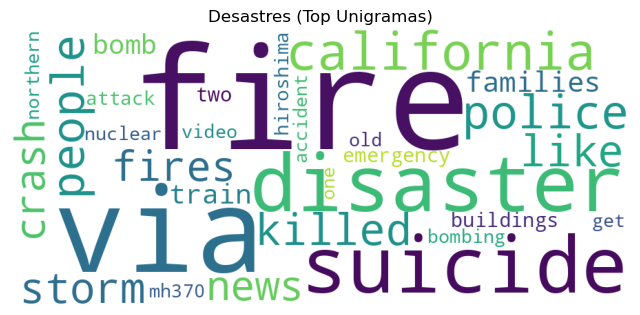

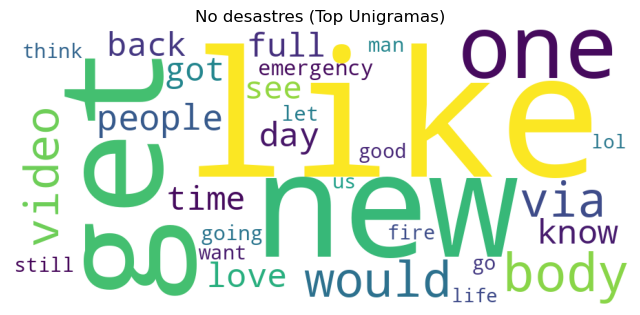

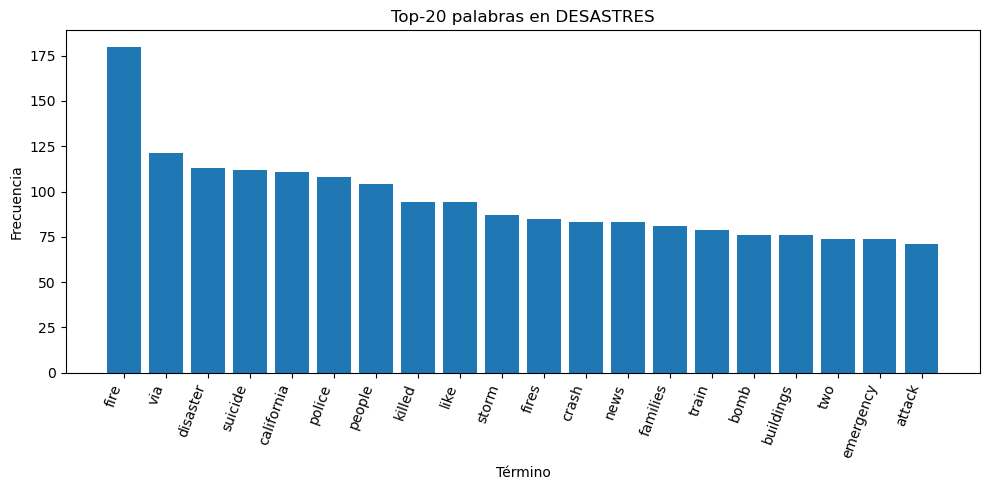

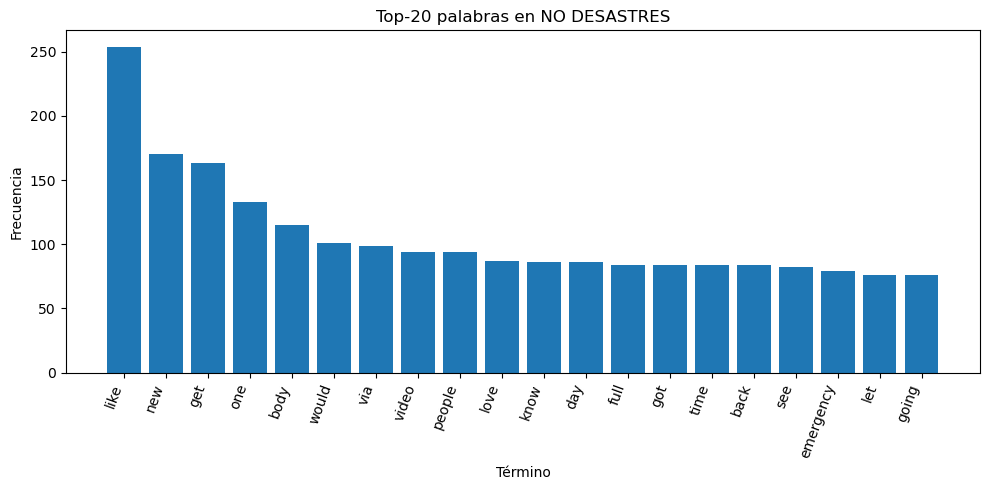

In [23]:
# ---- Frecuencias / n-gramas / plots
freq_out = ngrams_out = plots_wc = plots_hist = model_out = th_out = None

if RUN_FREQUENCIES:
    freq_out = computeFrequencies(data, minDf=VEC_MIN_DF, topK=TOPK_FREQ,
                                  verbose=True, log=LOGGING_ENABLED, logger=LOGGER)

if RUN_NGRAMS:
    ngrams_out = analyzeNgrams(data, nMax=NGRAM_MAX, minDf=VEC_MIN_DF,
                               topK=TOPK_NGRAMS, verbose=True)

if RUN_PLOTS and freq_out is not None:
    plots_wc  = generateWordClouds(freq_out['topPos'], freq_out['topNeg'],
                                   saveFigures=SAVE_FIGS, imagesDir=IMAGES_DIR, prefix="wc_")
    plots_hist= plotTopHistograms(freq_out['topPos'], freq_out['topNeg'],
                                  saveFigures=SAVE_FIGS, imagesDir=IMAGES_DIR, prefix="hist_")


1. **Limpieza agresiva del texto.**
   Bajamos ruido (URLs, @menciones, #hashtags, emojis, signos y rarezas Unicode). Resultado medible: longitud media del tweet bajó \~44% (101.2 -> 56.7 caracteres). ¿Por qué importa? Porque la señal léxica útil queda más densa y los modelos (TF-IDF y BERT) convergen mejor y con menos fuga de atención a basura.

2. **Conteo de palabras por clase (EDA).**
   Medimos frecuencias por clase (desastre=1 vs no=0) y el "lift" (qué tanto una palabra se inclina hacia una clase).
   Del log:

* **Top clase 1 (desastre):** `fire`, `disaster`, `suicide`, `storm`, `fires`, `crash`, `killed`, `california`, `police`, `news`, `families`, `train`…
* **Top clase 0 (no desastre):** `like`, `new`, `get`, `one`, `video`, `people`, `love`, `know`, `day`, `time`…
* **Intersección fuerte (aparecen en ambas):** `like`, `fire`, `get`, `new`, `via`, `people`, `video`, `emergency`, `disaster`, `police`, `body`, `burning`…

3. **Visualizaciones rápidas.**

* **Nube de palabras** y **barras Top-K** por clase para leer de un vistazo el léxico dominante y validar que la limpieza tuvo sentido (las nubes quedan "temáticas" sin emojis ni URLs ensuciando).

4. **¿Sirven bigramas/trigramas?**
   Sirven brigramas porque capturan contexto inmediato que un unigrama no diferencia:

* `forest fire`, `train crash`, `car accident`, `road closed`, `evacuate now`, `flash flooding`.
  Esto ayuda a desambiguar términos como "fire" (evento real vs metáfora tipo "dumpster fire" en bromas).
  Los trigramas pueden ayudar en frases hechas (`state of emergency`, `severe thunder storm`), pero con este tamaño de corpus tienden a ser escasos; aportan menos que los bigramas.

5. **Qué términos ayudan realmente al modelo.**

* **Muy útiles para "desastre" (señal positiva):** sustantivos/verbos de evento o daño (`fire`, `storm`, `flood`, `crash`, `earthquake`, `explosion`, `evacuate`, `rescue`, `killed`, `injured`), y frases que consolidan el hecho (`road closed`, `state of emergency`, `wildfire smoke`, `flash flood`).
* **Ruido o poco discriminativos:** `like`, `new`, `people`, `via`, `one`, `time`, `video` aparecen mucho en ambas clases -> TF-IDF los descuenta y los bigramas los contextualizan.
* **Términos "grises":** `police`, `news`, `california` salen en positivo pero también en no-desastre. Solos no bastan; con bigramas cambian: `police confirm`, `breaking news`, `california wildfire` sí agregan señal.

In [24]:
neg = "dumpster fire 😂"
# neg = "Great day at the park with friends, coffee and music."
pos = "Breaking: flash flooding downtown, roads closed and rescue teams deployed."

Oraciones para pruebas.

In [25]:
# --- Baseline (entrena y guarda) ---
if RUN_MODELS:
    model_out = trainEvaluateModels(
        data, testSize=TEST_SIZE, randomState=RANDOM_STATE,
        calibrateSVC=CALIBRATE_SVC, saveFigures=SAVE_FIGS,
        imagesDir=IMAGES_DIR, prefix="cm_", verbose=True,
        log=LOGGING_ENABLED, logger=LOGGER
    )

    if SAVE_BASELINE_MODEL and model_out and model_out.get('bestPipeline'):
        saved_path = saveBaselineModel(model_out['bestPipeline'])
        print(f"[baseline] Guardado en: {saved_path}")
        if LOGGING_ENABLED and LOGGER: LOGGER.info(f"[baseline] Guardado en: {saved_path}")

    # Predicción usando el pipeline en memoria
    print("\n[BASELINE - memoria]")
    print("NO desastre ->", predictWithModel(neg, modelKind="baseline", useSaved=False,
                                            threshold=0.5, pipeline=model_out['bestPipeline']))
    print("SÍ desastre ->", predictWithModel(pos, modelKind="baseline", useSaved=False,
                                            threshold=0.5, pipeline=model_out['bestPipeline']))
else: 
    # --- Baseline desde disco ---
    print("\n[BASELINE - disco]")
    print("NO desastre ->", predictWithModel(
        neg, modelKind="baseline", useSaved=True, threshold=0.5,
        paths={'baseline': BASELINE_LOAD_PATH}  # ./models/baseline_best.joblib
    ))
    print("SÍ desastre ->", predictWithModel(
        pos, modelKind="baseline", useSaved=True, threshold=0.5,
        paths={'baseline': BASELINE_LOAD_PATH}
    ))


[BASELINE - disco]


/nix/store/w708yz0d2n3six7w02m05s4xlff5ivvg-python3-3.12.11-env/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/nix/store/w708yz0d2n3six7w02m05s4xlff5ivvg-python3-3.12.11-env/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/nix/store/w708yz0d2n3six7w02m05s4xlff5ivvg-python3-3.12.11-env/lib/python3.12/site-packages/sklearn/base

NO desastre -> {'text': 'dumpster fire 😂', 'label': 1, 'probDesastre': 0.7000189136945982, 'threshold': 0.5, 'modelKind': 'baseline', 'source': 'disk', 'path': './models/baseline_best.joblib'}
SÍ desastre -> {'text': 'Breaking: flash flooding downtown, roads closed and rescue teams deployed.', 'label': 1, 'probDesastre': 0.7448723640314121, 'threshold': 0.5, 'modelKind': 'baseline', 'source': 'disk', 'path': './models/baseline_best.joblib'}


#### Baseline: TF-IDF + Clasificador lineal (qué hace y qué logramos)

* **Si `RUN_MODELS=True`:**
  1. Entrena varios pipelines combinando tres vectorizadores (TF-IDF unigramas, TF-IDF uni+bi, TF-IDF de caracteres 3–5) con tres clasificadores(LogisticRegression, Naive Bayes, LinearSVC).
  2. Evalúa todos en un split 80/20 estratificado y selecciona el mejor por F1.
  3. Guarda el mejor pipeline completo (vectorizador + modelo) en `./models/baseline_best.joblib`.
  4. Muestra ejemplos de inferencia en memoria (sin cargar de disco).
* **Si `RUN_MODELS=False`:**
  Salta el entrenamiento y carga desde disco el archivo `./models/baseline_best.joblib` para predecir de inmediato (lo mismo que haces con `useSaved=True`).

**¿Qué cambiamos / probamos?:**

* Probamos **tres vistas** del texto:
  * Palabras 1-gram (unigramas).
  * Palabras 1-2 (uni+bi).
  * **Caracteres 3–5** (captura typos, hashtags pegados, variaciones morfológicas).
* Probamos **tres clasificadores**: Logistic Regression (L2, `class_weight='balanced'`), Naive Bayes y LinearSVC.
* **Criterio de selección:** F1 en el conjunto de validación (test 20%).

**Resultados:**

* **Mejor combinación:** `tfidf_char (3–5)` + LogisticRegression
  * **F1 $\approx$ 0.768**, **Accuracy $\approx$ 0.804**.
* **Matriz de confusión (test 20%):** `tn=732, fp=137, fn=161, tp=493`.
  Interpretación rápida:
  * **TP=493:** desastres reales detectados correctamente.
  * **FP=137:** no-desastres marcados por error como desastre (falsos positivos).
  * **FN=161:** desastres que el modelo no detectó (falsos negativos).
  * **TN=732:** no-desastres detectados correctamente.
* Métricas derivadas de esa CM (aprox):
  * **Precision $\approx$ 0.783** (de lo que marcó como desastre, \~78% eran realmente desastres).
  * **Recall $\approx$ 0.754** (detectó \~75% de los desastres reales).
  * **F1 $\approx$ 0.768** (balance precisión/recall), consistente con el log.
* Se **guardó** la CM como imagen en `./images/cm_tfidf_char_LogReg.png`.
* Se **guardó** el modelo en `./models/baseline_best.joblib`.
* Los **ngrams de caracteres (3–5)** son muy buenos en tweets:
  * Aguantan errores ortográficos, hashtags y variantes (“fire/fires”, “burn/burnt”).
  * Capturan subcadenas útiles (“hirosh”, “wildfir”, “flood”, “suicid”…) incluso si la palabra exacta cambia.
* **Logistic Regression** con L2 es robusta, rápida y explicable; además, con `class_weight='balanced'` maneja bien el leve desbalance.

In [26]:
# --- BERT + CNN (entrena y guarda) ---
if RUN_BERTCNN:
    bert_out = trainEvaluateBertCnn(
        data, testSize=TEST_SIZE, randomState=RANDOM_STATE,
        max_len=BERT_MAX_LEN, batch_size=BERT_BATCH, epochs=BERT_EPOCHS, lr=BERT_LR,
        filters=CNN_FILTERS, kernel_size=CNN_KERNEL_SIZE, dropout=CNN_DROPOUT,
        bert_name=BERT_MODEL_NAME, trainable_bert=BERT_TRAINABLE, threshold=BERT_THRESHOLD
    )

    if SAVE_BERT_MODEL and bert_out:
        arts = saveBertArtifacts(bert_out['tokenizer'], bert_out['model'],
                                 meta_extra={'threshold': BERT_THRESHOLD})
        print(f"[bert] Guardado tokenizer en: {arts['tokenizer_dir']}")
        print(f"[bert] Guardado modelo en:    {arts['model_dir']}")
        if LOGGING_ENABLED and LOGGER:
            LOGGER.info(f"[bert] Guardado tokenizer en: {arts['tokenizer_dir']}")
            LOGGER.info(f"[bert] Guardado modelo en:    {arts['model_dir']}")

    # Predicción con objetos en memoria
    print("\n[BERT+CNN - memoria]")
    print("NO desastre ->", predictWithModel(neg, modelKind="bert", useSaved=False,
                                            threshold=BERT_THRESHOLD,
                                            tokenizer=bert_out['tokenizer'], model=bert_out['model']))
    print("SÍ desastre ->", predictWithModel(pos, modelKind="bert", useSaved=False,
                                            threshold=BERT_THRESHOLD,
                                            tokenizer=bert_out['tokenizer'], model=bert_out['model']))
else:
    # --- BERT+CNN desde disco ---
    print("\n[BERT+CNN - disco]")
    print("NO desastre ->", predictWithModel(
        neg, modelKind="bert", useSaved=True, threshold=BERT_THRESHOLD,
        paths={'tokenizer': BERT_TOKENIZER_LOAD_PATH,       # ./models/bert_cnn/tokenizer
            'model':     BERT_MODEL_LOAD_PATH}           # ./models/bert_cnn/model
    ))
    print("SÍ desastre ->", predictWithModel(
        pos, modelKind="bert", useSaved=True, threshold=BERT_THRESHOLD,
        paths={'tokenizer': BERT_TOKENIZER_LOAD_PATH,
            'model':     BERT_MODEL_LOAD_PATH}
    ))


[BERT+CNN - disco]


2025-08-30 18:03:26.672702: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

NO desastre -> {'text': 'dumpster fire 😂', 'label': 0, 'probDesastre': 0.3005896508693695, 'threshold': 0.5, 'modelKind': 'bert', 'source': 'disk', 'tokenizer_path': './models/bert_cnn/tokenizer', 'model_path': './models/bert_cnn/model'}
SÍ desastre -> {'text': 'Breaking: flash flooding downtown, roads closed and rescue teams deployed.', 'label': 1, 'probDesastre': 0.9989332556724548, 'threshold': 0.5, 'modelKind': 'bert', 'source': 'disk', 'tokenizer_path': './models/bert_cnn/tokenizer', 'model_path': './models/bert_cnn/model'}


#### BERT+CNN (PyTorch): qué hace y qué logramos

**Si `RUN_BERTCNN=True`:**

1. Tokeniza los tweets con `distilbert-base-uncased` (máx. 128 tokens).
2. Construye el modelo BERT (congelado) + CNN: una capa `Conv1d` + `GlobalMaxPool1d` sobre las representaciones contextuales de BERT y una capa lineal final (logits).
3. Entrena con RMSprop y early stopping (paciencia=2) usando un split 80/20 estratificado para test y, dentro del 80% de train, un 10% para validación interna.
4. Guarda artefactos en disco:
   * Tokenizer en `./models/bert_cnn/tokenizer`
   * Pesos + metadatos del modelo en `./models/bert_cnn/model` (`model_state.pt` y `meta.json`)
5. Muestra ejemplos de inferencia en memoria (sin cargar de disco).

**Si `RUN_BERTCNN=False`:**
Se salta el entrenamiento y carga desde disco (tokenizer + pesos) para predecir de inmediato con `useSaved=True`.

**¿Qué cambiamos / probamos?**

* **Encoder:** `distilbert-base-uncased` (PyTorch).
* **Cabeza CNN:** `filters=32`, `kernel_size=3`, `dropout=0.5`, `GlobalMaxPool1d`.
* **Entrenamiento:** `epochs=10` (se detuvo en la 7 por early stopping), `batch=32`, `lr=1e-3`, encoder congelado (`trainable_bert=False` por CPU).
* **Umbral de decisión:** `threshold=0.5`.
* **Dispositivo:** `cpu` (según el log).

**¿Por qué BERT+CNN?**

BERT aporta representaciones contextuales (la palabra “fire” no vale lo mismo en “dumpster fire 😂” que en “wildfire spreading”). La CNN encima actúa como un detector de *frases/trozos* informativos (n-gramas “suaves”) sobre esos embeddings, y el `GlobalMaxPool1d` recoge el *peak* de evidencia en toda la secuencia. Es más sensible al contexto que un TF-IDF clásico.

**Resultados:**

* **F1 $\approx$ 0.773**, **Accuracy $\approx$ 0.825** (mejor que la línea base: F1 $\approx$ 0.768, ACC $\approx$ 0.804).
* **Matriz de confusión (test 20%)**: `tn=802, fp=67, fn=200, tp=454`.
  Lectura rápida:

  * **Menos FP** (67 vs 137 del baseline) -> el modelo es más conservador al marcar “desastre”.
  * **Más FN** (200 vs 161) -> pierde algunos casos reales a umbral 0.5.

* **+2.1 pts** en *accuracy* (0.825 vs 0.804).
* **+0.5 pts** en *F1* (0.773 vs 0.768).
* Perfil de error diferente (menos FP, más FN), coherente con un modelo contextual que evita sobre-reaccionar a palabras aisladas fuera de contexto.

In [27]:
if LOGGING_ENABLED and LOGGER:
    logSection(LOGGER, "FIN DE EJECUCIÓN")
    LOGGER.info("Pipeline completado correctamente.")
    for h in LOGGER.handlers:
        try: h.flush()
        except Exception: pass
print(f"Logs en: {os.path.join(LOG_DIR, LOG_FILE_NAME)}")

Logs en: ./logs/pipeline.log


## Clasificación de Tweets en base a la neutralidad de sus palabras

Para el siguiente punto veremos la probabilidad de que un tweet sea positivo (esté hablando de un desastre), negativo (no esté hablando sobre un desastre natural) o neutral (no podamos asegurar niguna de las dos) en base a la cantidad de palabras que utiliza de cada categoría.

In [28]:
def classifyTweetWithWords(tweet: str, positive: pd.DataFrame, negative: pd.DataFrame):
    counts = {
        "positive": 0,
        "negative": 0,
    }
    for word in tweet.split(" "):
        positiveCount = pd.Series([0.0])
        if positive[positive["token"] == word].any().any():
            positiveCount =  positive[positive["token"] == word]["lift_pos"]

        negativeCount = pd.Series([0.0])
        if  negative[negative["token"] == word].any().any():
            negativeCount =  negative[negative["token"] == word]["lift_neg"]

        # print(word, positiveCount, negativeCount, sep="\n")
        isPositive = (positiveCount > negativeCount).all()

        if isPositive:
            counts["positive"] += 1
        else:
            counts["negative"] += 1
    return counts

Si realizamos un ejemplo con un tweet random tenemos:

In [29]:
classifyTweetWithWords("77 mile marker 31 south mooresville iredell vehicle accident ramp closed 8 6 1 18 pm", freq_out["freqDf"], freq_out["freqDf"])

{'positive': 12, 'negative': 4}

Por lo que si aplicamos esa lógica para todos los tweets tenemos:

In [30]:
dataSet = loadDataset()
data = dataSet["df"]

def compute(text, positive=False):
    result = classifyTweetWithWords(text, freq_out["freqDf"], freq_out["freqDf"])

    if positive:
        return result["positive"] / (result["positive"] + result["negative"])
    else:
        return result["negative"] / (result["positive"] + result["negative"])

# data
        
data["positive"] = data["text"].apply(lambda row: compute(row, True))
data["negative"] = data["text"].apply(compute)
data

,id,keyword,location,text,target,positive,negative
0,1,NaN,NaN,deeds reason may allah forgive us,1,0.333333,0.666667
1,4,NaN,NaN,forest fire near la ronge sask canada,1,0.714286,0.285714
2,5,NaN,NaN,residents asked shelter place notified officer...,1,0.727273,0.272727
3,6,NaN,NaN,13 000 people receive evacuation orders califo...,1,0.857143,0.142857
4,7,NaN,NaN,got sent photo ruby smoke pours school,1,0.000000,1.000000
...,...,...,...,...,...,...,...
7608,10869,NaN,NaN,two giant cranes holding bridge collapse nearb...,1,0.875000,0.125000
7609,10870,NaN,NaN,control wild fires california even northern pa...,1,0.777778,0.222222
7610,10871,NaN,NaN,m1 94 01 04 utc 5km volcano hawaii,1,1.000000,0.000000
7611,10872,NaN,NaN,police investigating e bike collided car littl...,1,0.705882,0.294118


Siendo:
* positive: La probabilidad de que todo el tweet en sí mismo sea positivo.
* negative: La probabilidad de que todo el tweet en sí mismo sea negativo.

Ahora podemos obtener los 10 tweets más negativos y positivos:

In [31]:
print("TOP POSITIVOS")
data.sort_values(['positive'], ascending=False).head(10)

TOP POSITIVOS


,id,keyword,location,text,target,positive,negative
10,16,NaN,NaN,three people died heat wave far,1,1.0,0.0
7612,10873,NaN,NaN,latest homes razed northern california wildfir...,1,1.0,0.0
1222,1761,buildings%20burning,"New Orleans ,Louisiana",burning buildings media outrage,1,1.0,0.0
1234,1775,buildings%20on%20fire,"Manchester, NH",fire destroys two buildings 2nd street,1,1.0,0.0
1235,1776,buildings%20on%20fire,"Tulsa, Oklahoma",multiple buildings fire downtown hinton,1,1.0,0.0
1242,1790,buildings%20on%20fire,Scotland,two buildings fire,1,1.0,0.0
7509,10741,wreckage,NaN,wreckage conclusively confirmed mh370 malaysia...,1,1.0,0.0
7511,10744,wreckage,Mumbai,wreckage conclusively confirmed mh370 malaysia...,1,1.0,0.0
7512,10745,wreckage,khanna,wreckage conclusively confirmed mh370 malaysia...,1,1.0,0.0
7515,10748,wreckage,Africa,malaysia pm confirms wreckage belongs mh370,1,1.0,0.0


In [32]:
print("TOP NEGATIVOS")
data.sort_values(['negative'], ascending=False).head(10)

TOP NEGATIVOS


,id,keyword,location,text,target,positive,negative
7571,10822,wrecked,Glasgow,see u night wee barra get absolutely wrecked,0,0.0,1.0
4,7,NaN,NaN,got sent photo ruby smoke pours school,1,0.0,1.0
7582,10834,wrecked,NaN,cramer iger 3 words wrecked disney stock cnbc,0,0.0,1.0
7580,10832,wrecked,London,cramer iger 3 words wrecked disney stock,0,0.0,1.0
15,23,NaN,NaN,man,0,0.0,1.0
7578,10830,wrecked,NaN,wrecked,0,0.0,1.0
7577,10829,wrecked,#NewcastleuponTyne #UK,gone relax thought wife wrecked cake goner min...,0,0.0,1.0
7576,10827,wrecked,NaN,wrecked,0,0.0,1.0
7575,10826,wrecked,TN,bright side wrecked,0,0.0,1.0
7574,10825,wrecked,Global,cramer 3 words wrecked dis stock,0,0.0,1.0


Gracias a la variable `target` podemos apreciar que la gran mayoría de los tweets están siendo clasificados correctamente, al menos en los extremos.

Por último intentaremos entrenar el modelo nuevamente con estas nuevas variables de positive y negative, talvez con estas pistas el modelo mejore en su predicción.


[tfidf_uni + LogReg]  F1=0.764  ACC=0.798
              precision    recall  f1-score   support

           0      0.822     0.826     0.824       869
           1      0.767     0.761     0.764       654

    accuracy                          0.798      1523
   macro avg      0.794     0.794     0.794      1523
weighted avg      0.798     0.798     0.798      1523


[tfidf_uni + NB]  F1=0.757  ACC=0.810
              precision    recall  f1-score   support

           0      0.794     0.902     0.844       869
           1      0.841     0.688     0.757       654

    accuracy                          0.810      1523
   macro avg      0.817     0.795     0.801      1523
weighted avg      0.814     0.810     0.807      1523


[tfidf_uni + LinSVC]  F1=0.748  ACC=0.793
              precision    recall  f1-score   support

           0      0.800     0.849     0.824       869
           1      0.782     0.717     0.748       654

    accuracy                          0.793      1523
   

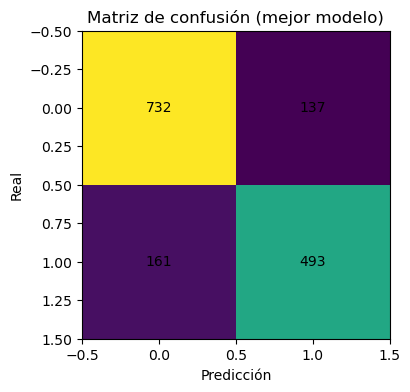

In [33]:
model_out = trainEvaluateModels(
        data, testSize=TEST_SIZE, randomState=RANDOM_STATE,
        calibrateSVC=CALIBRATE_SVC, saveFigures=SAVE_FIGS,
        imagesDir=IMAGES_DIR, prefix="wp_", verbose=True,
        log=LOGGING_ENABLED, logger=LOGGER
    )

Como se puede ver por la imagen generada abajo, el mejor modelo entrenado se comporta muy similar al modelo anteior, por lo que realmente no hubo una mejora significativa en el performance del mejor modelo obtenido luego del entrenamiento.